In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "etf_adjusted_close.csv"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

prices = pd.read_csv(
    DATA_PATH,
    index_col="Date",
    parse_dates=True,
)

returns = prices.pct_change(fill_method=None).dropna()

print("Price sample:", prices.index.min(), "to", prices.index.max())
print("Prices shape:", prices.shape)
print("Returns shape:", returns.shape)

prices.head()

Price sample: 2007-04-11 00:00:00 to 2020-04-01 00:00:00
Prices shape: (3268, 12)
Returns shape: (3267, 12)


,SPY,QQQ,IWM,EFA,EEM,IEF,TLT,LQD,HYG,GLD,DBC,VNQ
Date,,,,,,,,,,,,
2007-04-11,110.289658,39.279694,66.941124,52.894066,30.795134,59.255993,58.066200,62.582520,44.114380,67.080002,23.717676,45.059521
2007-04-12,110.779778,39.590656,67.391281,53.247246,31.310007,59.313496,58.079468,62.676716,44.143967,66.989998,23.857685,44.752880
2007-04-13,111.285194,39.670624,67.824745,53.423836,31.463705,59.212826,57.900051,62.570763,44.063625,67.839996,23.988363,45.258251
2007-04-16,112.341995,40.034893,68.758461,53.987541,31.837688,59.277557,58.219078,62.623730,44.046719,68.400002,23.801685,45.315048
2007-04-17,112.640648,40.123745,68.550041,53.994328,31.666058,59.529251,58.544727,62.965149,44.025558,68.000000,23.559000,45.905624


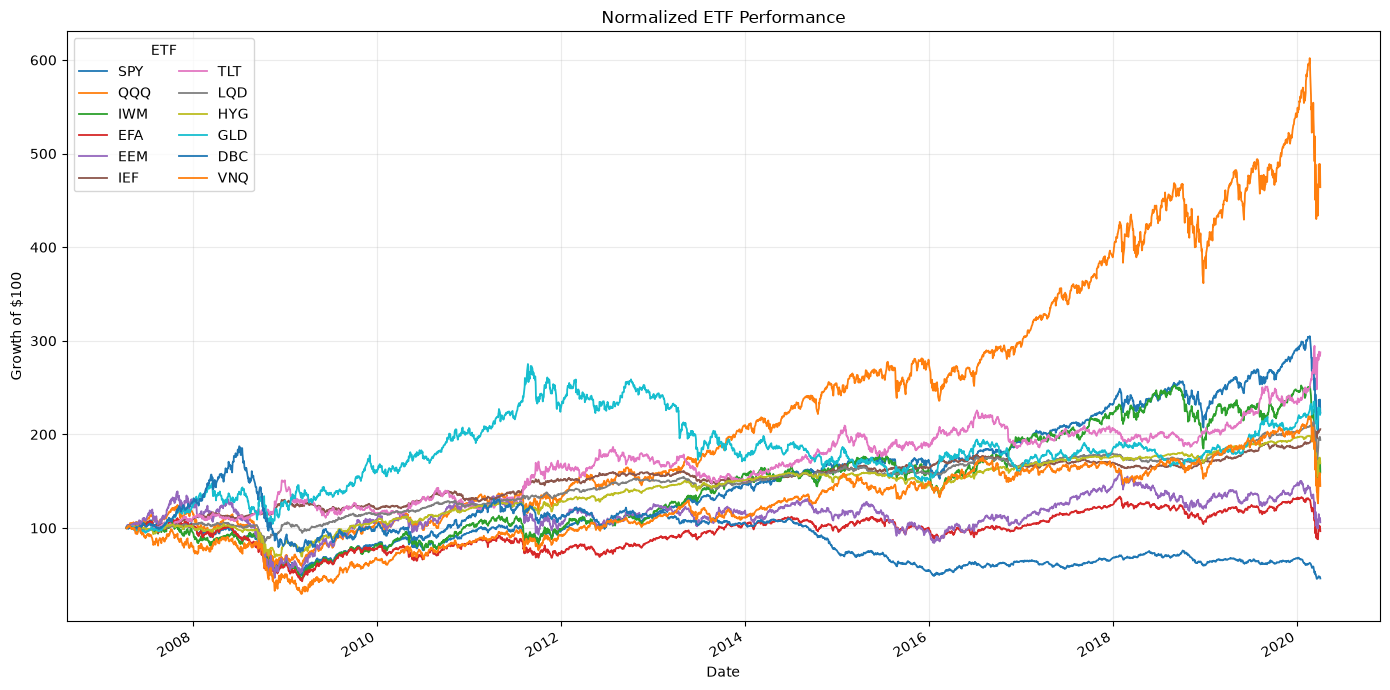

In [3]:
normalized_prices = prices.div(prices.iloc[0]).mul(100)

ax = normalized_prices.plot(
    figsize=(14,7),
    linewidth=1.3,
)

ax.set_title("Normalized ETF Performance")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $100")
ax.legend(title="ETF", ncol=2)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "normalized_etf_performance.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

In [10]:
TRADING_DAYS = 252

summary = pd.DataFrame({
    "annualized_return": returns.mean() * TRADING_DAYS,
    "annualized_volatility": returns.std() * np.sqrt(TRADING_DAYS),
    "skewness": returns.skew(),
    "excess_kurtosis": returns.kurtosis(),
    "minimum_daily_return": returns.min(),
    "maximum_daily_return": returns.max(),
})

summary["historical_var_95"] = returns.quantile(0.05)

summary["historical_cvar_95"] = returns.apply(
    lambda x: x[x <= x.quantile(0.05)].mean()
)

summary.round(4)

,annualized_return,annualized_volatility,skewness,excess_kurtosis,minimum_daily_return,maximum_daily_return,historical_var_95,historical_cvar_95
SPY,0.0834,0.2068,-0.0456,15.6939,-0.1094,0.1452,-0.0194,-0.0325
QQQ,0.1426,0.2198,-0.1477,9.1953,-0.1198,0.1216,-0.0224,-0.0337
IWM,0.0678,0.2518,-0.4978,7.6687,-0.1327,0.0915,-0.0243,-0.0388
EFA,0.0254,0.2368,-0.0462,13.6925,-0.1116,0.1589,-0.0222,-0.0371
EEM,0.0529,0.3118,0.5995,17.5680,-0.1617,0.2277,-0.0281,-0.0466
IEF,0.0580,0.0686,0.1346,3.2403,-0.0251,0.0343,-0.0067,-0.0094
TLT,0.0929,0.1506,0.0976,4.5617,-0.0667,0.0752,-0.0146,-0.0203
LQD,0.0552,0.0899,-0.1346,76.9648,-0.0911,0.0977,-0.0063,-0.0118
HYG,0.0477,0.1199,0.6473,40.9959,-0.0810,0.1227,-0.0089,-0.0182
GLD,0.0783,0.1815,-0.0510,7.2129,-0.0878,0.1129,-0.0178,-0.0270


## Correlation Structure Across Market Regimes

Let $r_{i,t}$ and $r_{j,t}$ denote the daily returns of assets $i$ and $j$.
Their sample correlation over a period containing $T$ observations is

$$
\widehat{\rho}_{ij}
=
\frac{
\sum_{t=1}^{T}
(r_{i,t}-\bar r_i)(r_{j,t}-\bar r_j)
}{
\sqrt{
\sum_{t=1}^{T}(r_{i,t}-\bar r_i)^2
}
\sqrt{
\sum_{t=1}^{T}(r_{j,t}-\bar r_j)^2
}
},
$$

where

$$
\bar r_i = \frac{1}{T}\sum_{t=1}^{T}r_{i,t}
$$

is the sample mean return of asset $i$.

The resulting correlation matrix is

$$
\widehat{P}
=
\begin{bmatrix}
1 & \widehat{\rho}_{12} & \cdots & \widehat{\rho}_{1n} \\
\widehat{\rho}_{21} & 1 & \cdots & \widehat{\rho}_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
\widehat{\rho}_{n1} & \widehat{\rho}_{n2} & \cdots & 1
\end{bmatrix}.
$$

Each entry satisfies

$$
-1 \leq \widehat{\rho}_{ij} \leq 1.
$$

A positive value indicates that two assets tend to move in the same direction,
a negative value indicates that they tend to move in opposite directions, and
a value close to zero indicates a weak linear relationship. The diagonal
elements are equal to one because each asset is perfectly correlated with
itself.

The heatmaps compare the estimated correlation matrices over three market
regimes:

1. the 2008 financial crisis;
2. the relatively stable period from 2012 to 2017;
3. the initial COVID-19 market crash.

The objective is to examine whether the dependence structure among asset
returns changes during periods of market stress. In particular, an increase in
positive correlations among risky assets would indicate a reduction in the
benefits of diversification.

The three periods contain different numbers of observations. Therefore, the
estimated correlations have different levels of sampling uncertainty and
should be interpreted descriptively rather than as a formal statistical test
of structural change.

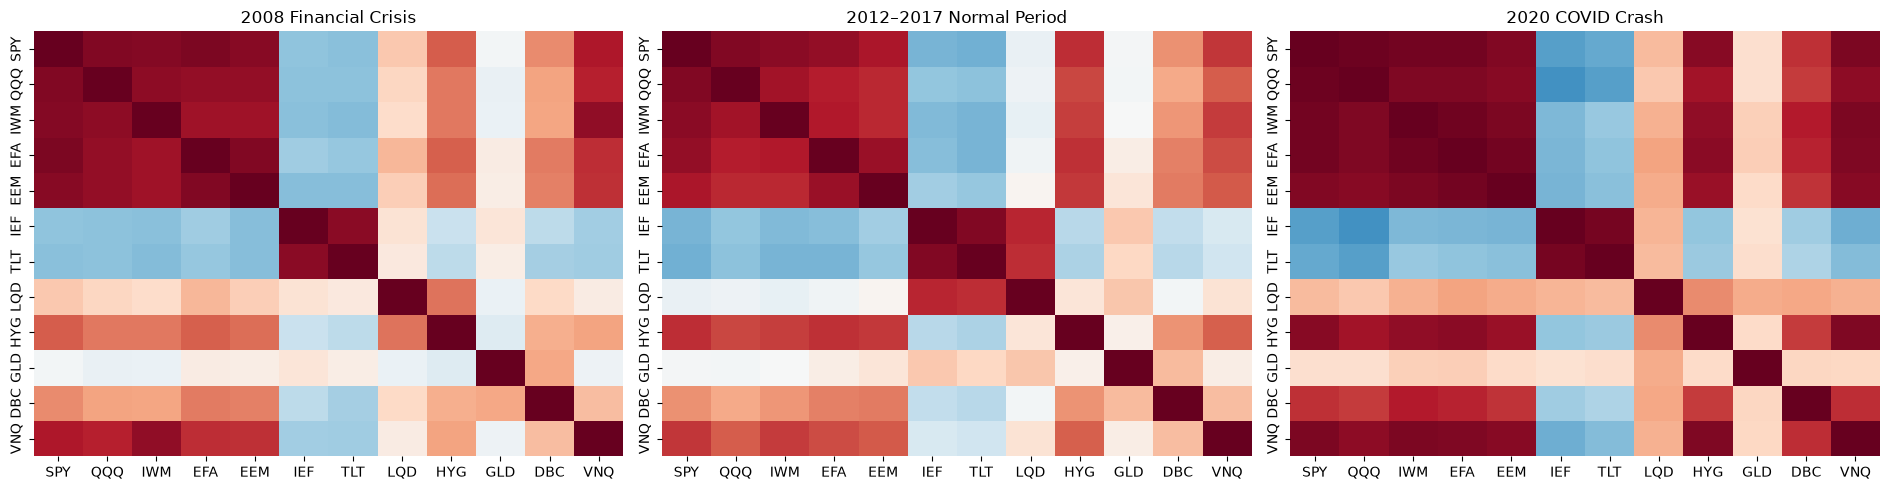

In [5]:
normal_returns = returns.loc["2010-01-01":"2019-12-31"]
crisis_2008 = returns.loc["2008-01-01":"2009-06-30"]
crisis_2020 = returns.loc["2020-02-01":"2020-04-01"]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

periods = {
    "2008 Financial Crisis": crisis_2008,
    "2012–2017 Normal Period": normal_returns,
    "2020 COVID Crash": crisis_2020,
}

for ax, (title, period_returns) in zip(axes, periods.items()):
    sns.heatmap(
        period_returns.corr(),
        cmap="RdBu_r",
        center=0,
        vmin=-1,
        vmax=1,
        ax=ax,
        cbar=False,
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Interpretation

The broad correlation structure is relatively stable across the three
periods. Equity, international-equity, and real-estate ETFs remain strongly
positively correlated, while Treasury ETFs generally maintain low or negative
correlations with risky assets.

The crisis periods do not produce a uniform increase in correlation across all
asset classes. This suggests that changes in crisis-period risk may be more
visible through volatility, drawdown, and tail losses than through a complete
reorganization of the correlation matrix.

## Rolling Volatility

Let $r_t$ denote the daily return of an asset. For a rolling window of length
$h$, the local sample mean at time $t$ is

$$
\bar r_{t,h}
=
\frac{1}{h}
\sum_{s=t-h+1}^{t} r_s.
$$

The rolling sample variance is

$$
\widehat{\sigma}_{t,h}^{\,2}
=
\frac{1}{h-1}
\sum_{s=t-h+1}^{t}
\left(r_s-\bar r_{t,h}\right)^2.
$$

The corresponding rolling daily volatility is

$$
\widehat{\sigma}_{t,h}
=
\sqrt{
\frac{1}{h-1}
\sum_{s=t-h+1}^{t}
\left(r_s-\bar r_{t,h}\right)^2
}.
$$

Assuming approximately 252 trading days per year, the annualized rolling
volatility is

$$
\widehat{\sigma}_{t,h}^{\mathrm{ann}}
=
\sqrt{252}\,
\widehat{\sigma}_{t,h}.
$$

This analysis uses $h=63$ trading days, which corresponds to approximately one
calendar quarter:

$$
\frac{252}{4}=63.
$$

The 63-day window provides a compromise between responsiveness and estimation
noise. A shorter window reacts more rapidly to new market information but
produces a noisier estimate, while a longer window is smoother but reacts more
slowly to sudden changes.

Rolling volatility is used to examine whether the scale of the return
distribution is stable over time. Large changes in
$\widehat{\sigma}_{t,h}^{\mathrm{ann}}$ indicate that a constant-volatility
assumption would be inappropriate over the full sample.

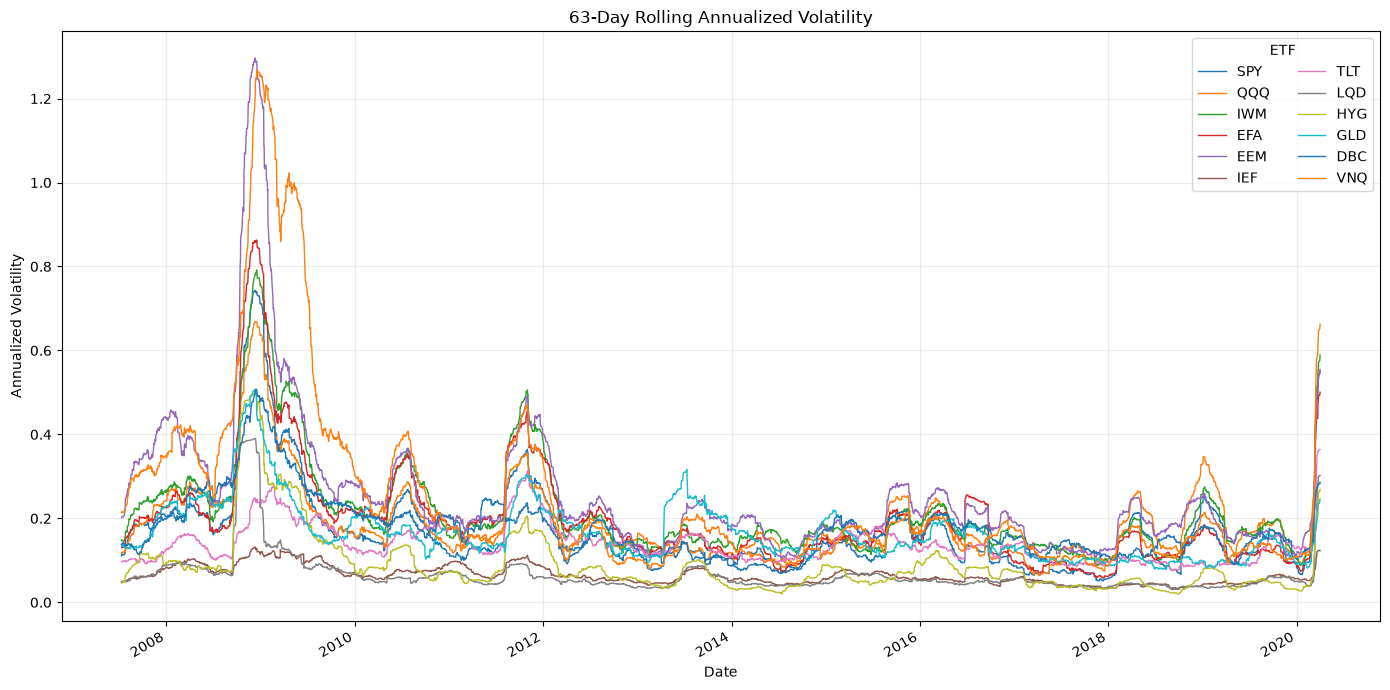

In [6]:
rolling_volatility = (
    returns.rolling(63).std()
    * np.sqrt(TRADING_DAYS)
)

ax = rolling_volatility.plot(
    figsize=(14, 7),
    linewidth=1,
)

ax.set_title("63-Day Rolling Annualized Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility")
ax.legend(title="ETF", ncol=2)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### Interpretation

The rolling estimates show that volatility is strongly time-varying. The 2008
financial crisis produces the largest and most persistent volatility increase,
particularly for emerging-market equities and real estate. Treasury and
investment-grade bond ETFs remain comparatively stable.

Volatility also rises sharply across risky assets during the initial COVID-19
crash. However, the dataset ends on April 1, 2020. Consequently, the final
63-day estimates still contain many pre-crisis observations, and the COVID
volatility peak is right-censored. Its magnitude should not be compared
directly with the complete 2008 episode.

The result provides empirical motivation for evaluating portfolio models
outside the constant-variance framework and for considering downside and tail
risk measures such as CVaR and stochastic dominance.

## Drawdown Analysis

Let $r_t$ denote the asset return at time $t$. Starting from unit wealth,
the cumulative wealth process is

$$
W_t = \prod_{s=1}^{t}(1+r_s).
$$

The running maximum of the wealth process is

$$
M_t = \max_{1\leq s\leq t} W_s.
$$

The drawdown at time $t$ is defined as

$$
D_t = \frac{W_t}{M_t}-1.
$$

Since $W_t\leq M_t$, drawdown satisfies

$$
-1\leq D_t\leq 0.
$$

A drawdown of zero indicates that the asset is at a new running maximum.
A negative drawdown measures the percentage loss relative to the previous
peak. The maximum drawdown over the sample is

$$
\operatorname{MDD} = \min_t D_t.
$$

Under this sign convention, a more negative MDD represents a more severe
peak-to-trough loss. Drawdown is path-dependent: it depends on the ordering
of returns, rather than only on their marginal distribution.

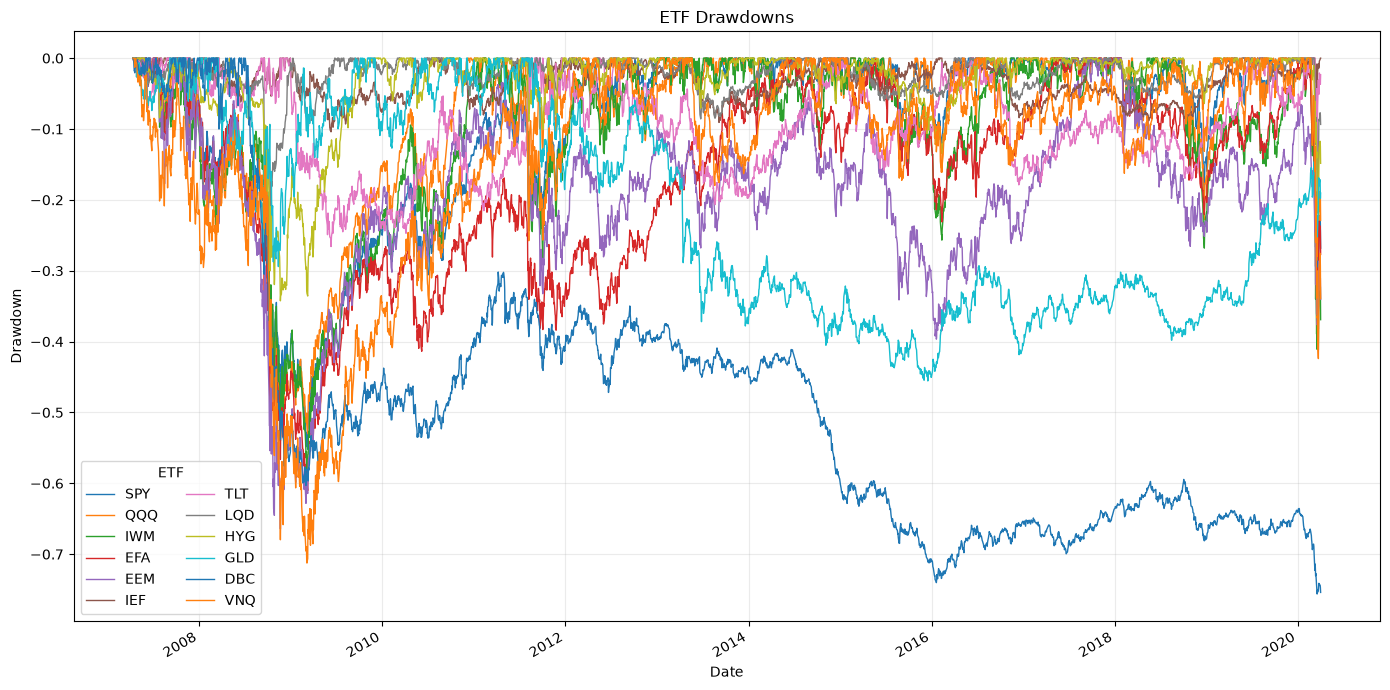

In [7]:
wealth_index = (1 + returns).cumprod()
running_peak = wealth_index.cummax()
drawdowns = wealth_index.div(running_peak).sub(1)

ax = drawdowns.plot(
    figsize=(14, 7),
    linewidth=1,
)

ax.set_title("ETF Drawdowns")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.legend(title="ETF", ncol=2)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [8]:
drawdown_summary = pd.DataFrame({
    "maximum_drawdown": drawdowns.min(),
    "maximum_drawdown_date": drawdowns.idxmin(),
}).sort_values("maximum_drawdown")

drawdown_summary

,maximum_drawdown,maximum_drawdown_date
DBC,-0.756197,2020-03-18
VNQ,-0.712539,2009-03-06
EEM,-0.664343,2008-11-20
EFA,-0.610373,2009-03-09
IWM,-0.586400,2009-03-09
SPY,-0.551894,2009-03-09
QQQ,-0.534040,2008-11-20
GLD,-0.455550,2015-12-17
HYG,-0.342466,2008-11-20
TLT,-0.265854,2009-06-10


### Interpretation

The drawdown paths measure cumulative losses from previous peaks. Unlike
volatility, drawdown penalizes only adverse movements and captures prolonged
sequences of moderate losses. It is used here as an out-of-sample performance
metric rather than as an optimization objective.

## Empirical Tail Risk

Portfolio risk is expressed in terms of losses rather than returns. For an asset
return $R$, define the loss as

$$
L=-R.
$$

For confidence level $\alpha\in(0,1)$, Value-at-Risk is the $\alpha$-quantile
of the loss distribution:

$$
\operatorname{VaR}_{\alpha}(L)
=
\inf\left\{
\ell:
\mathbb{P}(L\leq \ell)\geq\alpha
\right\}.
$$

For a continuous loss distribution, Conditional Value-at-Risk is

$$
\operatorname{CVaR}_{\alpha}(L)
=
\mathbb{E}
\left[
L
\mid
L\geq \operatorname{VaR}_{\alpha}(L)
\right].
$$

Thus, $\operatorname{VaR}_{0.95}$ identifies the threshold exceeded by the
worst 5% of losses, while $\operatorname{CVaR}_{0.95}$ measures the average
loss within that tail.

Unlike variance, VaR and CVaR focus specifically on adverse outcomes. CVaR also
accounts for the magnitude of losses beyond the VaR threshold.